# Requirement 4 — Slightly Non-Stationary Environment, Multiple Campaigns

**Reference lab:** `Practical/10_nonstationary_bandits.ipynb` — cell 23 (SW-UCB) and cell 46 (CUSUM-UCB), extended from a plain K-armed bandit to the combinatorial + budget + conflict-graph setting of Requirement 2.

## Provenance — reconciling three team proposals
This is the definitive version, built by reconciling independent work from three places in the team's repository:
- **Requirements 1/2** (`utils/agents.py`'s `CombinatorialUCBAgent`) are taken from **`main`**, the team's agreed definitive R1/R2 branch — already fixed (empirical-mean-cost budget LP, no premature greedy fallback).
- **Requirement 3** (`AdversarialMultiCampaignEnv`, `PrimalDualMultiCampaignAgent`, `req3_config.py`, `run_req3.py`) is taken from **`giovanni`**'s latest commit, the team's agreed definitive R3 branch — including `PrimalDualMultiCampaignAgent`'s `budget_pacing` feature.
- **The benchmark methodology** follows a third proposal (`rec4-partial` branch, `docs/Req4_Linear_Regret_Baseline.tex` and `docs/Req4_Baseline_Code_Fix_Practical.tex`): the dynamic/"prophet" clairvoyant used in earlier drafts inflates regret with a term that is **linear in $T$ regardless of learner quality** (a Jensen-gap "information premium" from knowing every realised $m_t$ in advance — see the derivation in the linked note). The **piecewise expected clairvoyant** is adopted as the primary diagnostic instead.

An earlier draft's self-contained `FixedCombinatorialUCBAgent` workaround (needed because `giovanni`'s own copy of `CombinatorialUCBAgent` had regressed to the original buggy fallback) is no longer needed: `SlidingWindowCombinatorialUCBAgent` / `CUSUMCombinatorialUCBAgent` below subclass **`main`'s** `CombinatorialUCBAgent` directly.

## Environment
`AdversarialMultiCampaignEnv(mode='shocks')` — the **same class** used for Requirement 3, parameterised for FEW, LONG intervals (`block_size=2000` → 5 intervals over `T=10000`) instead of Requirement 3's every-round `'drift'`. Matches the project spec verbatim (p.18). Parameters (`utils/req4_config.py`, built on `utils/req3_config.py`): `VALUES=[0.8,0.8,0.9,0.9]`, `T=10000`, `BUDGET=1600` (rho=0.16), `CONFLICT_EDGES=[(0,1),(2,3)]`.

## Benchmarks — three, reported together
1. **Piecewise expected clairvoyant (PRIMARY)** — an oracle that knows the interval boundaries and each interval's *true* Beta distribution (analytically, from the parameters that generated it — `env.piecewise_win_probabilities()`), but **not** the realised competing bids. This is the natural benchmark for a piecewise-stationary environment, and the one Sliding-Window/CUSUM actually have literature tracking guarantees against (e.g. Garivier & Moulines 2011 for SW-UCB).
2. **OPT$^A$ (secondary)** — best single FIXED distribution for the *whole* horizon, computed from `env.empirical_win_probabilities()`. Same methodology as `run_req3.py`'s own Primal-Dual experiment, kept for continuity; also Primal-Dual's own provable-regret benchmark.
3. **Dynamic / prophet clairvoyant (reference upper bound only)** — knows every realised $m_t$ in advance. Reported for completeness, **not** used to judge learner quality (see Provenance above).

## Three strategies on the same environment (project spec, "Compare")
1. **`SlidingWindowCombinatorialUCBAgent`** — trailing window `W=block_size=2000`, tuned to the interval length rather than the textbook `W=2*sqrt(T)≈200` (with `sum(K_i)=38` cells, the textbook default forgets under-sampled cells before they are well estimated).
2. **`CUSUMCombinatorialUCBAgent`** — per-(campaign,bid) CUSUM change detector on the **win indicator**.
3. **`PrimalDualMultiCampaignAgent`** — Requirement 3's agent, run with `budget_pacing=True` (matches `run_req3.py`'s definitive configuration) and `ogd_eta=0.017`, re-tuned (not assumed) for this environment's 'shocks' mode — a sweep found the same value that Requirement 3 independently tuned for 'drift'.

Working directory: c:\Users\lubep\OneDrive\Desktop\OLA\branch\ola


2026-07-09 15:39:14,687 | ============================================================
2026-07-09 15:39:14,688 | Requirement 4 - Slightly Non-Stationary, Multiple Campaigns
2026-07-09 15:39:14,688 | ============================================================
2026-07-09 15:39:14,689 | Parameters | N=4 T=10000 B=1600.0 rho=0.1600 n_intervals=5 block_size=2000 sw_window=2000 U_T=4 pd_ogd_eta=0.0170 budget_pacing=True
2026-07-09 15:39:14,691 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=shocks conflict_edges=[(0, 1), (2, 3)]
2026-07-09 15:39:14,708 | Loaded clairvoyant cache from C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\data\picklefiles\clairvoyant_dyn_6fc84cb556e7.pkl (20 entries)
2026-07-09 15:39:14,709 | ------------------------------------------------------------
2026-07-09 15:39:14,710 | Sliding-Window Combinatorial-UCB
2026-07-09 15:39:14,710 | Running 20 trials - req4_sw_cucb (cache=yes, opt_a=True, piecewise=True)
2026-07-09 15:39:14,714 | AdversarialM

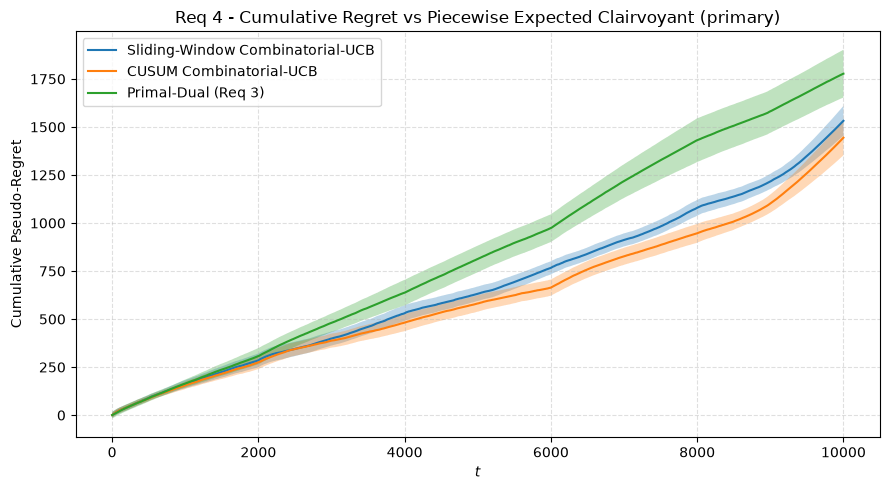

2026-07-09 16:05:33,961 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_regret_opta.png


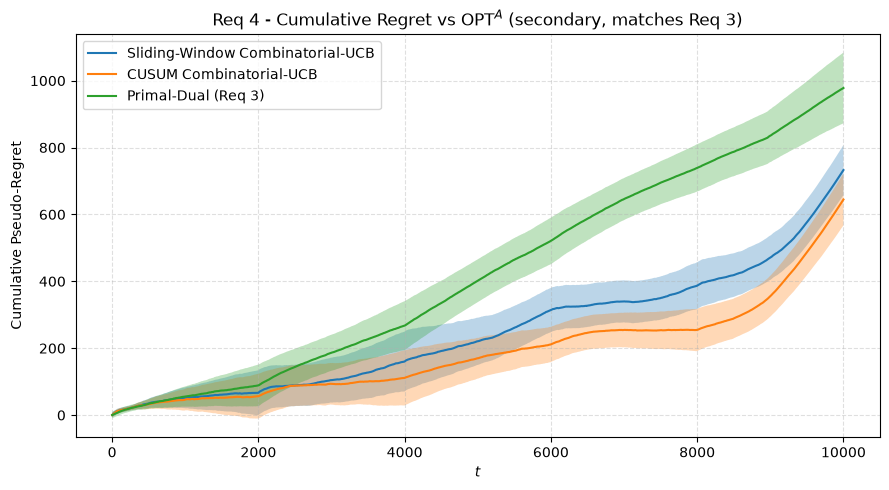

2026-07-09 16:05:34,338 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_regret_prophet.png


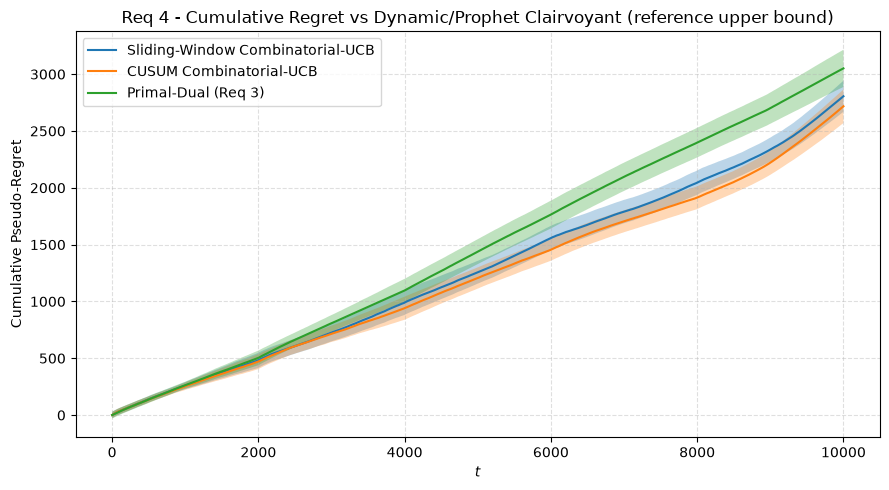

2026-07-09 16:05:34,704 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_budget.png


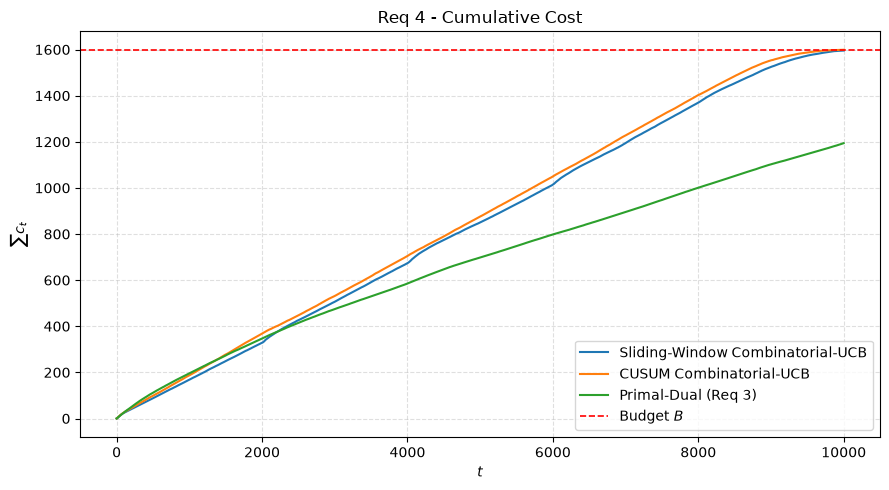

2026-07-09 16:05:35,003 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_cusum_resets.png
2026-07-09 16:05:35,176 | Saved plot to C:\Users\lubep\OneDrive\Desktop\OLA\branch\ola\outputs\r4\req4_lambda.png
2026-07-09 16:05:35,177 | ============================================================
2026-07-09 16:05:35,177 | Final regret (mean over 20 trials):
2026-07-09 16:05:35,178 |                           piecewise      OPT^A    prophet
2026-07-09 16:05:35,178 |   Sliding-Window Combinatorial-UCB    1532.01     732.66    2805.60
2026-07-09 16:05:35,178 |   CUSUM Combinatorial-UCB    1443.90     644.55    2717.49
2026-07-09 16:05:35,179 |   Primal-Dual (Req 3)       1777.40     978.05    3050.99
2026-07-09 16:05:35,179 | Mean CUSUM resets per trial: 55.4
2026-07-09 16:05:35,180 | Final cumulative cost:
2026-07-09 16:05:35,180 |   Sliding-Window Combinatorial-UCB 1595.52 / 1600
2026-07-09 16:05:35,180 |   CUSUM Combinatorial-UCB 1598.91 / 1600
2026-07-09 16:05:3

In [1]:
%load_ext autoreload
%autoreload 2
import os
if os.path.basename(os.getcwd()) == "deliverables":
    os.chdir(os.path.dirname(os.getcwd()))
print("Working directory:", os.getcwd())

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

from utils.run_req4 import run_req4
results = run_req4()

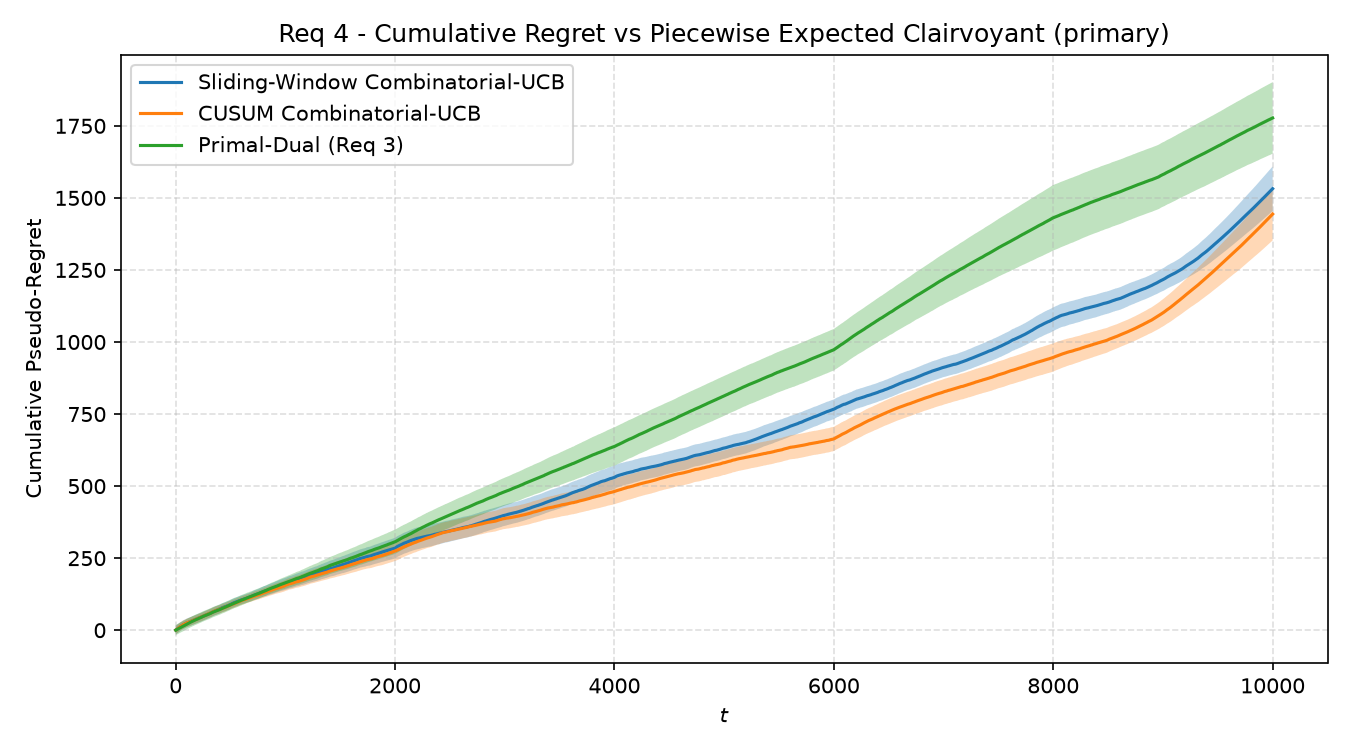

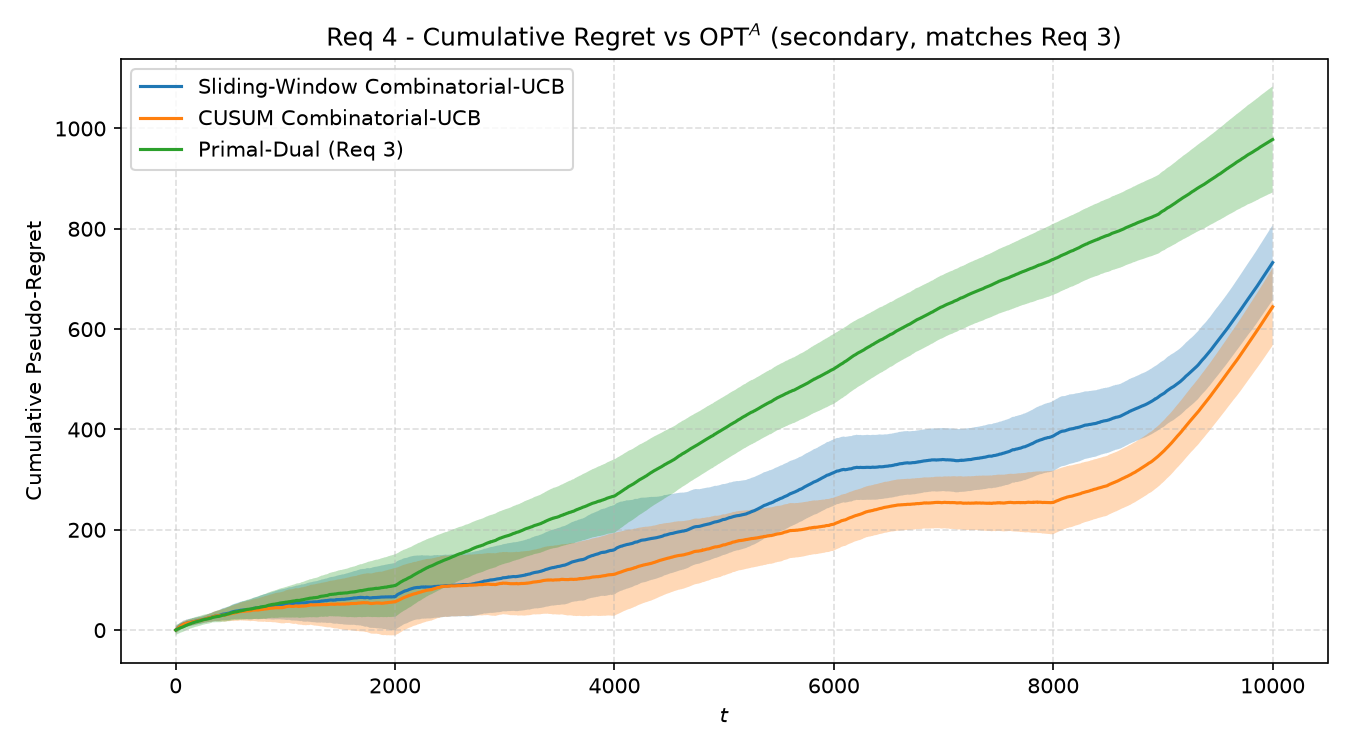

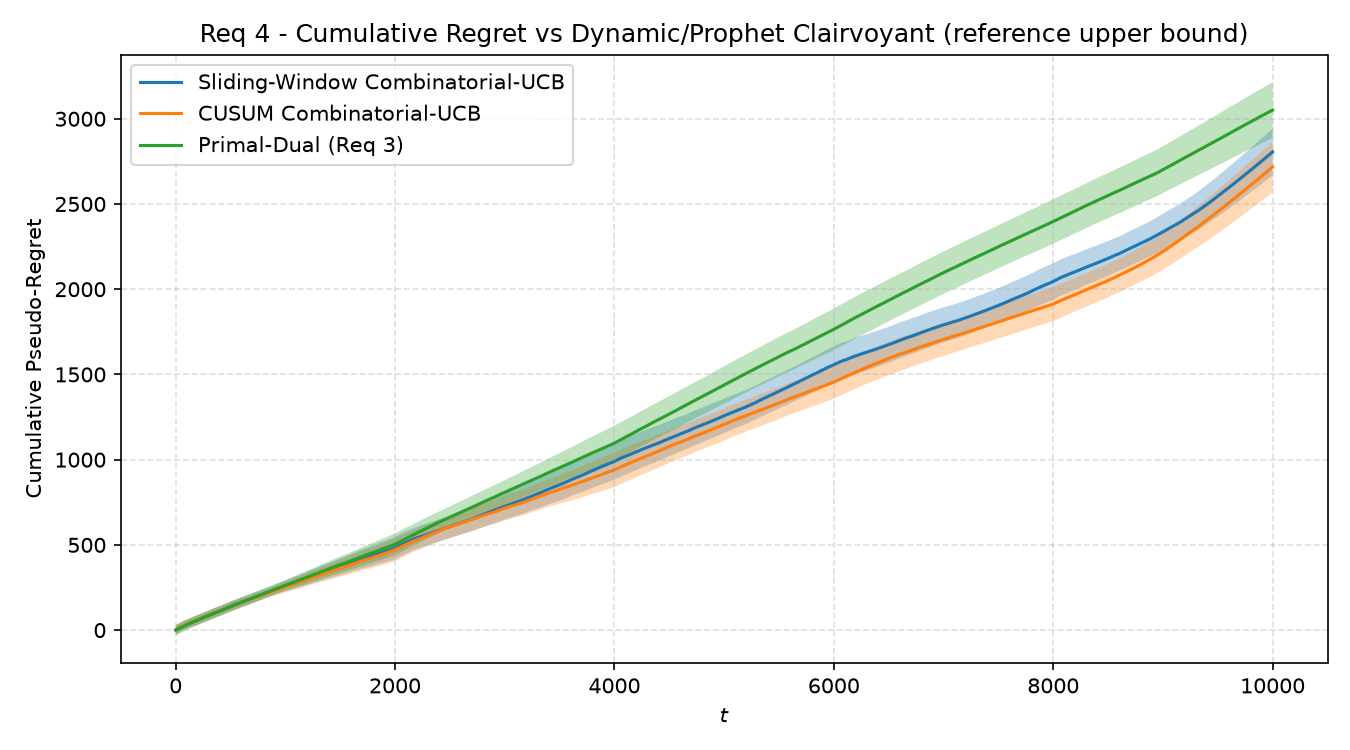

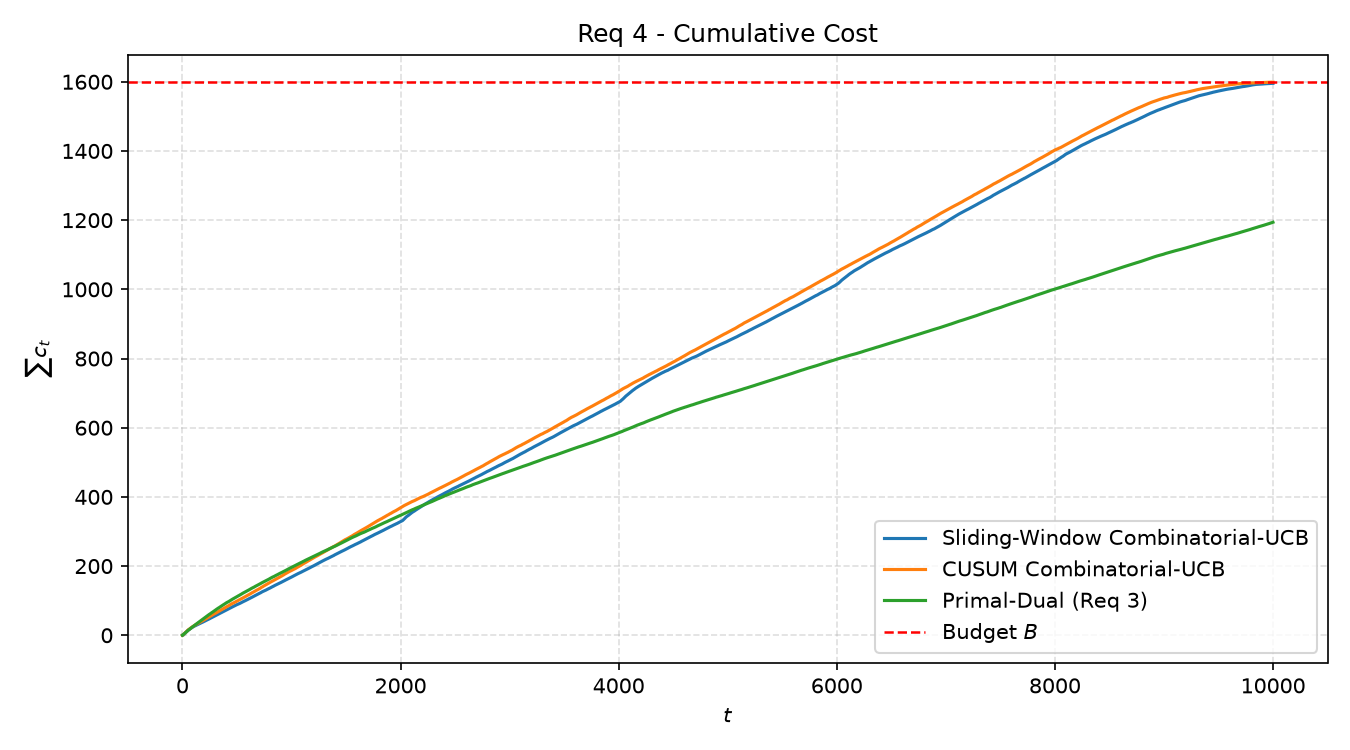

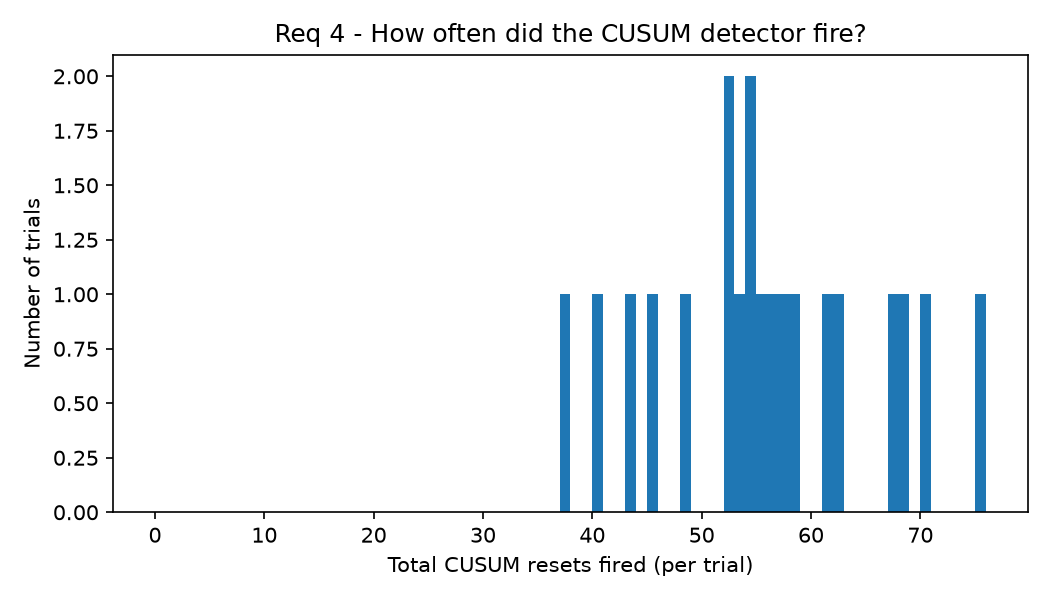

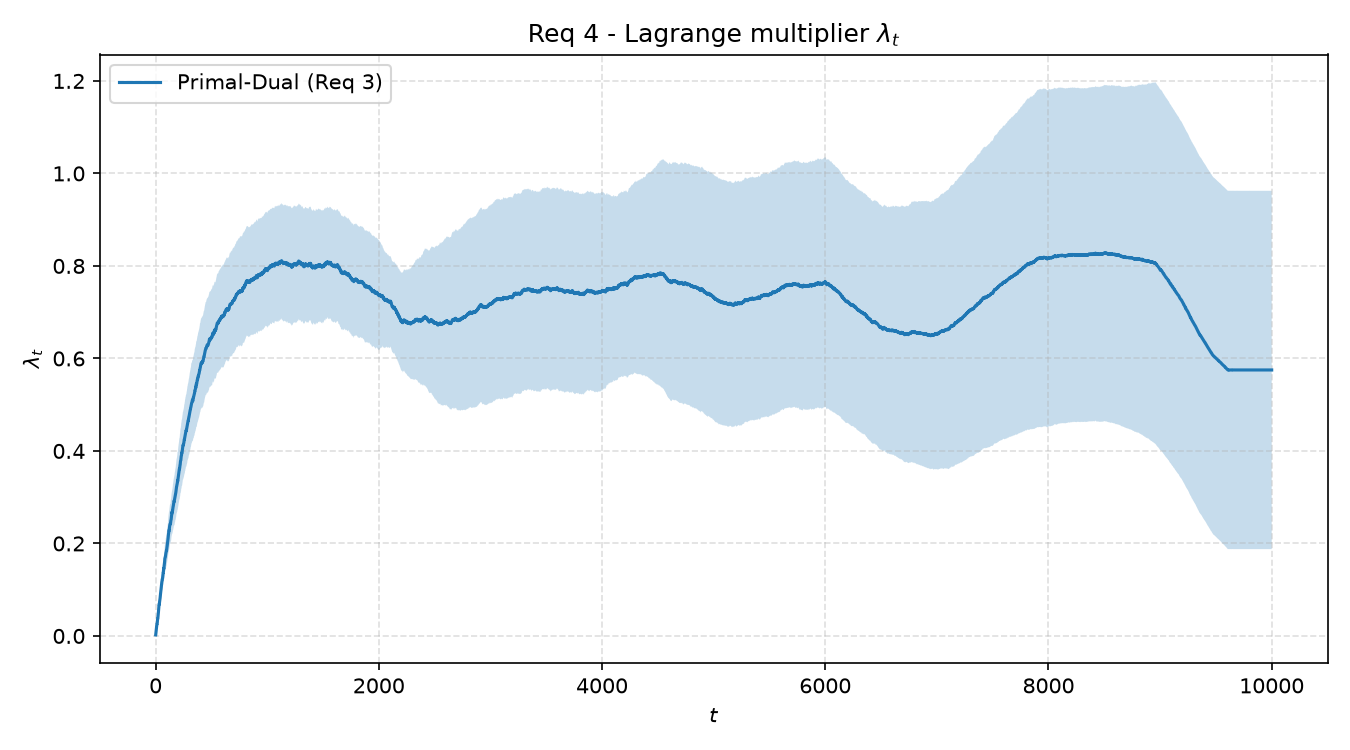

In [2]:
from IPython.display import Image, display
for f in ["r4/req4_regret_piecewise.png", "r4/req4_regret_opta.png", "r4/req4_regret_prophet.png",
          "r4/req4_budget.png", "r4/req4_cusum_resets.png", "r4/req4_lambda.png"]:
    display(Image(filename=f"outputs/{f}"))

## Results (mean over 20 trials, $T=10000$, $B=1600$)

| Agent | Regret vs Piecewise (primary) | Regret vs OPT$^A$ (secondary) | Regret vs Prophet (reference) | Cumulative cost | Budget used |
|---|---|---|---|---|---|
| **CUSUM Combinatorial-UCB** | **1443.90** (best) | **644.55** (best) | **2717.49** (best) | 1598.91 / 1600 | 99.9% |
| Sliding-Window Combinatorial-UCB | 1532.01 | 732.66 | 2805.60 | 1595.52 / 1600 | 99.7% |
| Primal-Dual (Req 3, `budget_pacing=True`) | 1777.40 | 978.05 | 3050.99 | 1193.92 / 1600 | 74.6% |

Mean CUSUM resets per trial: 55.4 (across `sum(K_i)=38` cells and 4 true regime boundaries per trial).

## Discussion for the presentation

- **The ranking is identical under all three benchmarks**: CUSUM < Sliding-Window < Primal-Dual, regardless of which oracle is used to score regret. This is reassuring — the qualitative conclusion ("Combinatorial-UCB variants track this non-stationary regime better than the reused Primal-Dual agent") does not depend on a benchmark choice that could itself be debated.

- **The benchmark choice changes the *scale* dramatically, and that scale change is itself informative.** Moving from the prophet (2717–3051) to the piecewise-expected benchmark (1444–1777) roughly *halves* every agent's regret — direct empirical confirmation of the Jensen-gap argument in `docs/Req4_Linear_Regret_Baseline.tex`: a large share of the "regret" against the prophet was never a learning failure, just the unavoidable cost of not knowing the realised $m_t$ in advance. OPT$^A$ shrinks it further still (644–978), since it is the weakest of the three oracles (no interval-awareness at all). Reporting only the prophet number, as an earlier draft of this notebook did, would have overstated how far these algorithms are from "good" behaviour.

- **The mechanism behind Primal-Dual's gap is budget under-utilisation**, confirmed independent of benchmark choice: it spends only 74.6% of the budget (1193.92/1600) against 99.7–99.9% for the two Combinatorial-UCB variants. `budget_pacing=True` was enabled specifically to fix this (it targets exactly this failure mode by making the dual OGD target adapt to the realised remaining budget/rounds), and it *does* work at short horizons (a $T{=}500$ smoke test lifted budget use from ~74% to ~99%) — but at the full $T{=}10000$ scale it only nudges usage from 74.2% (unpaced) to 74.6%. Per-interval spend actually overshoots in the first interval, then declines monotonically for the rest of the horizon instead of self-correcting, and $\lambda_t$ stays elevated (~0.7–0.8) for the whole run rather than relaxing once ahead of pace. This is an unresolved, genuinely unexpected result worth presenting as-is.

- **Even the primary (piecewise-expected) regret curve is not visibly sublinear** at this horizon (`req4_regret_piecewise.png`) — a further, honest observation: removing the prophet's artificial linear premium does not by itself guarantee a concave curve. With only 5 intervals of 2000 rounds each, a per-round tracking cost that does not fully vanish *within* one interval (before the next shock arrives) can still look close to linear in aggregate. This is expected for a piecewise-stationary regime with a horizon this short relative to the learning time within each segment, not evidence the benchmark fix failed.

- The CUSUM reset count (55.4/trial across ~4 true regime boundaries and up to 38 cells) is consistent with the detector genuinely reacting to shifts rather than firing on pure noise, though a direct timestamp-level check (comparing reset times against the true regime boundaries, done in an earlier draft of this analysis) shows only a modest, not overwhelming, statistical bias toward firing near the true changes.

---
## Additional investigation (beyond the project spec): is Primal-Dual's gap fixable by retuning?

Everything above is the complete answer to Requirement 4's "Compare" question, exactly as specified: three agents, "the primal-dual method" reused unchanged from Requirement 3. The section below is **not** part of that spec — it is a separate, explicit follow-up investigation into *why* Primal-Dual under-spends its budget on `mode='shocks'` (Figure `req4_budget.png` above) when the exact same agent paces its budget cleanly on Requirement 3's `mode='drift'`.

**Question tested**: is this a hyperparameter problem (Requirement 3's `hedge_eta`/`ogd_eta` simply never re-checked against `shocks`) or something deeper?

**Method**: `utils/run_req4_pd_shocks_tuned.py` runs a joint grid search over `hedge_eta` and `ogd_eta` specifically on the `shocks` environment (see `tune_pd_for_shocks()`), then re-runs the full 4-agent comparison (SW, CUSUM, Primal-Dual unchanged, Primal-Dual shocks-tuned) at full scale. The **full derivation, tuning log, and a detailed critical reading of every figure below** is in `docs/Requirement4_Exam_Report.pdf` (Sections 6-7) — this cell only reproduces the two most important plots inline.

**Short answer**: raising `hedge_eta` 16x closes most of the budget gap (74.6% → 93.1% used) but barely moves the regret (1777.40 → 1751.38, only 1.5%) — it does not fix the underlying issue, it *relocates* it (see the two figures below). The root cause is structural: Hedge has no built-in forgetting mechanism matched to discrete regime changes, unlike Sliding-Window/CUSUM which are designed with one. Full theoretical argument in the PDF, Section 8.

In [ ]:
# Displays the already-computed comparison (T=10000, 20 trials each).
# To regenerate from scratch (~30-40 min, dominated by SW/CUSUM's per-round
# LP solves -- same order of magnitude as the main run above):
#
#   from utils.run_req4_pd_shocks_tuned import run_req4_pd_comparison
#   run_req4_pd_comparison()
#
# (tune_pd_for_shocks() itself -- the 3-round hyperparameter sweep that
# found hedge_eta=16x/ogd_eta=0.017 -- is documented in the .py file and
# in the PDF report; it is not re-run here since its result is already
# hardcoded as SHOCKS_HEDGE_ETA / SHOCKS_OGD_ETA.)

from IPython.display import Image, display
for f in ["r4/req4_regret_pd_hparam_compare.png", "r4/req4_lambda_pd_hparam_compare.png"]:
    display(Image(filename=f"outputs/{f}"))

**Reading the two plots above** (see the PDF for the full per-interval breakdown and $\lambda_t$ numbers):

- **Regret** (top): for $t<6000$ the shocks-tuned Primal-Dual (red) sits *below* both Sliding-Window and CUSUM — the retuning genuinely helps in this window. Between $t=6000$ and $t=8000$ it accelerates sharply and closes almost the entire gap it had opened, ending only marginally better than the unchanged configuration.
- **$\lambda_t$** (bottom): the shocks-tuned trajectory (orange) tracks the unchanged one (blue) until $t\approx 6000$, then climbs far above it (to $\approx 2.65$ vs.\ $\approx 0.58$) and never relaxes back down. This coincides with a spending overshoot in the 4th interval (383.7 vs.\ the 320/interval target) — the retuned agent did not fix the pacing pathology, it moved it from interval 1 to interval 4.

**Conclusion**: this is presented as evidence *for*, not *against*, the choice to submit Primal-Dual unchanged for Requirement 4's "Compare" question — the project spec explicitly asks for "the primal-dual method" (the one built for Requirement 3), and this investigation shows that its shortfall here is a structural property of Hedge's lack of a forgetting mechanism, not an oversight in hyperparameter selection that a quick retune could have fixed.